In [1]:
import arviz as az
from risk_experiment.cogmodels.fit_probit import build_model, get_data
from risk_experiment.cogmodels.utils import extract_intercept_gamma
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/Users/gdehol/mambaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
bids_folder = '/data/ds-risk'

# Group level

In [22]:
sessions = ['3t2', '7t2', None]
sessions = [None]

df = []

for session in sessions:

    # if session is None:
    #     model_label = 'probit_full_session'
    # else:
    model_label = 'probit_full'

    data = get_data(model_label, session, bids_folder)
    model = build_model(model_label, data, session, bids_folder)

    if session is None:
        idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_trace.netcdf')
    else:
        idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_ses-{session}_trace.netcdf')
    intercept, gamma = extract_intercept_gamma(idata, model, data, group=True)
    intercept = intercept.groupby(['subject', 'n_safe', 'risky_first']).mean()
    gamma = gamma.groupby(['subject', 'n_safe', 'risky_first']).mean()

    intercept  = intercept.stack([1,2])['intercept']
    gamma  = gamma.stack([1,2])['gamma']

    # intercept = intercept.groupby(['subject').mean().mean(1).rename('intercept')
    # # gamma = gamma.groupby('subject').mean().mean(1).rename('gamma')

    rnp = np.clip(np.exp(intercept/gamma),0, 1).rename('rnp')
    gdf, rnp_aligned = gamma.to_frame('gamma').align(rnp, join='inner', axis=0)
    gdf['rnp'] = rnp_aligned
    df.append(gdf)

df = pd.concat(df, keys=['both' if session is None else session for session in sessions], names=['session'])

100%|██████████| 30/30 [00:01<00:00, 19.63it/s]
/Users/gdehol/mambaforge/lib/python3.11/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_94969/947850757.py:24: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept  = intercept.stack([1,2])['intercept']
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_94969/947850757.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  gamma  = gamma.stack([1,2])['ga

In [24]:
import arviz as az

def get_ci(d):
    return az.hdi(d.values.ravel())

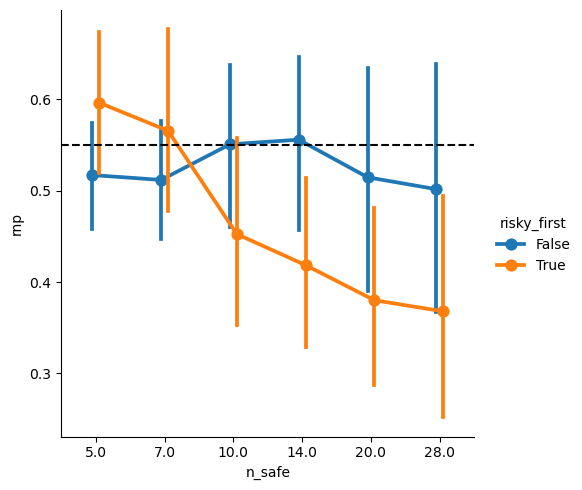

In [25]:
g = sns.catplot(data=df.xs('both', level='session').reset_index(), x='n_safe', hue='risky_first', y='rnp', kind='point', errorbar=get_ci, dodge=.1)
g.map(lambda *args, **kwargs: plt.axhline(0.55, c='k', ls='--'))

In [33]:
df.xs(5.0, level='n_safe')

gamma       rnp
session subject risky_first chain draw                    
both    1       False       0     0     2.748027  0.534465
                                  1     2.726065  0.527983
                                  2     2.468720  0.537355
                                  3     2.694658  0.536967
                                  4     2.479687  0.493702
...                                          ...       ...
                True        3     995   2.333011  0.548709
                                  996   2.129388  0.548265
                                  997   2.235833  0.514075
                                  998   2.247867  0.583367
                                  999   2.294496  0.553009

[8000 rows x 2 columns]

In [30]:
df.unstack('risky_first')['rnp'].groupby('n_safe').apply(lambda x: (x[True] > x[False]).mean())

n_safe
5.0     0.99975
7.0     0.96400
10.0    0.00125
14.0    0.00000
20.0    0.00000
28.0    0.00200
dtype: float64

In [32]:
# Drop all non-unique indices
df = df[~df.index.duplicated(keep=False)]


In [33]:
df

,,,,,,gamma,rnp
session,subject,n_safe,risky_first,chain,draw,,


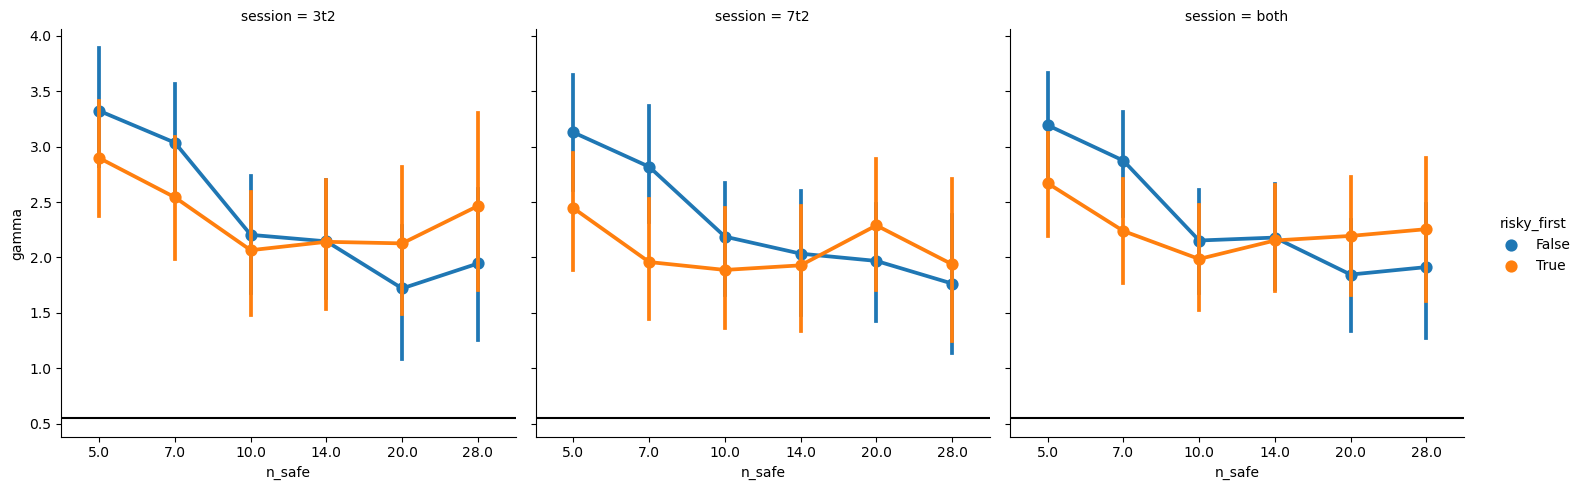

In [7]:
g = sns.catplot(data=df.reset_index(), x='n_safe', hue='risky_first', y='gamma', kind='point', errorbar=get_ci, col='session')
g.map(lambda *args, **kwargs: plt.axhline(0.55, c='k',))

In [10]:
# Subjectwise

In [11]:
sessions = ['3t2', '7t2', None]

df = []

for session in sessions:

    if session is None:
        model_label = 'probit_full_session'
    else:
        model_label = 'probit_full'

    data = get_data(model_label, session, bids_folder)
    model = build_model(model_label, data, session, bids_folder)
    if session is None:
        idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_trace.netcdf')
    else:
        idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_ses-{session}_trace.netcdf')
    intercept, gamma = extract_intercept_gamma(idata, model, data, group=False)

    intercept  = intercept.stack([1,2])['intercept'].droplevel('session')
    gamma  = gamma.stack([1,2])['gamma'].droplevel('session')

    # intercept = intercept.groupby(['subject').mean().mean(1).rename('intercept')
    # # gamma = gamma.groupby('subject').mean().mean(1).rename('gamma')

    rnp = np.clip(np.exp(intercept/gamma),0, 1).rename('rnp')
    df.append(gamma.to_frame('gamma').join(rnp))

df = pd.concat(df, keys=['both' if session is None else session for session in sessions], names=['session'])

100%|██████████| 30/30 [00:01<00:00, 28.54it/s]
/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/arraylike.py:405: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 30/30 [00:01<00:00, 26.98it/s]
/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/arraylike.py:405: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 30/30 [00:01<00:00, 19.92it/s]
/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/arraylike.py:405: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
rnp_ci = df['rnp'].groupby(['session', 'subject', 'n_safe', 'risky_first']).apply(lambda x: pd.Series(get_ci(x), index=['low', 'high']).T).unstack(-1)

In [13]:
risk_averse = rnp_ci.groupby(['session', 'n_safe', 'risky_first']).apply(lambda x: (x['high'] < 0.55).sum())
risk_seeking = rnp_ci.groupby(['session', 'n_safe', 'risky_first']).apply(lambda x: (x['low'] > 0.55).sum())
risk_neutral = rnp_ci.groupby(['session', 'n_safe', 'risky_first']).apply(lambda x: ((x['low'] < 0.55) & (x['high'] > 0.55)).sum())

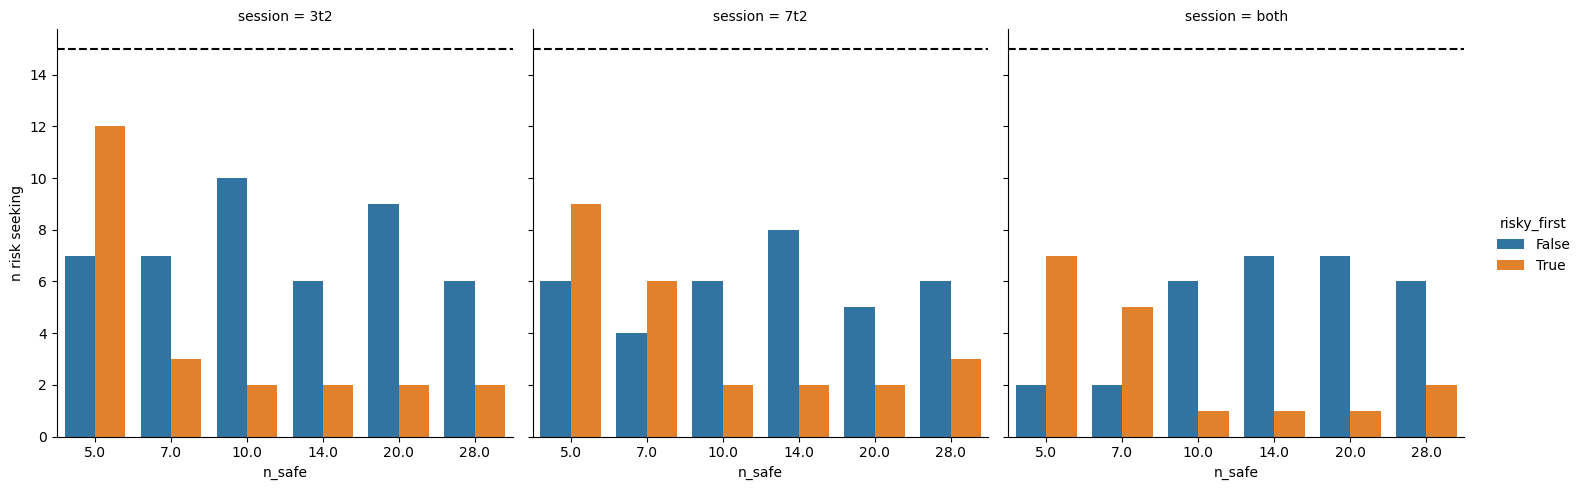

In [14]:
g = sns.catplot(x='n_safe', y='n risk seeking', hue='risky_first', col='session', data=risk_seeking.to_frame('n risk seeking').reset_index(), kind='bar')
g.map(lambda *args, **kwargs: plt.axhline(30/2., c='k', ls='--'))

In [15]:
rnp

subject  n_safe  risky_first  chain  draw
02       5.0     False        0      0       5.722641e-01
                                     1       5.793337e-01
                                     2       6.444099e-01
                                     3       5.927641e-01
                                     4       6.058913e-01
                                                 ...     
32       28.0    True         3      995     2.183890e-02
                                     996     5.679894e-02
                                     997     2.469187e-02
                                     998     1.735340e-12
                                     999     1.110538e-01
Name: rnp, Length: 2880000, dtype: float64

In [16]:
risk_seeking = df['rnp'].groupby(['session', 'n_safe', 'risky_first']).apply(lambda x: (rnp.mean() > 0.55).sum())

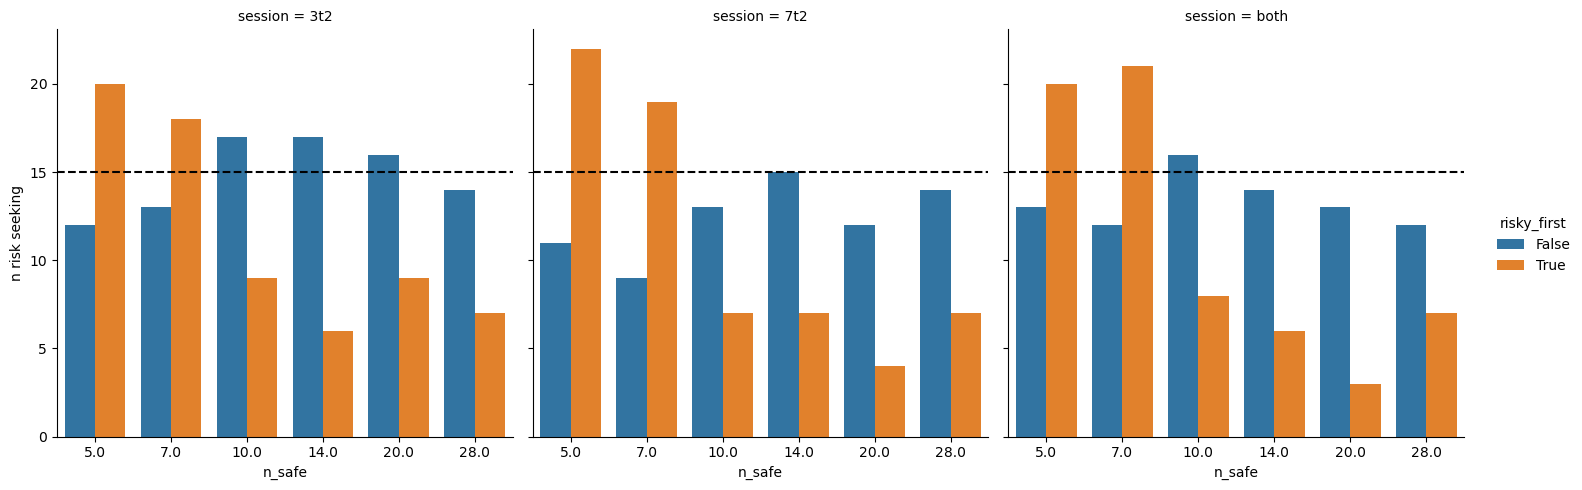

In [17]:
risk_seeking = df['rnp'].groupby(['session', 'subject', 'n_safe', 'risky_first']).mean().groupby(['session', 'n_safe', 'risky_first']).apply(lambda x: (x> 0.55).sum())

g = sns.catplot(x='n_safe', y='n risk seeking', hue='risky_first', col='session', data=risk_seeking.to_frame('n risk seeking').reset_index(), kind='bar')
g.map(lambda *args, **kwargs: plt.axhline(30/2., c='k', ls='--'))

In [19]:
from scipy.stats import norm

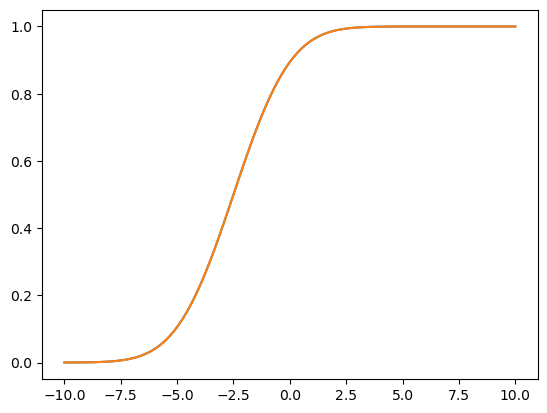

In [28]:
mu = -2.5
sd = 2
x = np.linspace(-10, 10, 100, True)
plt.plot(x, norm(mu, sd).cdf(x))

plt.plot(x, norm.cdf((x - mu)/sd))